In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
import phd_parser as pp

In [3]:
from phd_parser.raman.btc655n import extract_lines, split_lines, parse_metadata_lines, parse_data_lines, read_export

In [4]:
MOCK_RAMAN_FILE = Path(r"..\tests\raman\btc655n\test_TiO2.txt")

In [5]:
lines = extract_lines(MOCK_RAMAN_FILE)
meta_lines, header_line, data_lines = split_lines(lines)

In [6]:
meta = parse_metadata_lines(meta_lines)
meta

{'File Version': 'BWSpec4.04_00',
 'Date': '2026-03-25 17:03:42',
 'title': 'RBU',
 'model': 'BTC655N',
 'c code': 'RBU',
 'operator': '',
 'port1': 0.0,
 'baud1': 3.0,
 'pixel_start': 0.0,
 'pixel_end': 2047.0,
 'step': 1.0,
 'units': 0.0,
 'bkcolor': 16777215.0,
 'show_mode': 3.0,
 'data_mode': 0.0,
 'pixel_mode': 0.0,
 'intigration times(ms)': 10000.0,
 'average number': 5.0,
 'time_multiply': 1.0,
 'spectrometer_type': 74.0,
 'yaxis': 1.0,
 'yaxis_min': 0.0,
 'yaxis_max': 65535.0,
 'xaxis': 1.0,
 'xaxis_min': 8.0,
 'xaxis_max': 2026.0,
 'irrands_DispWLMin': 100.0,
 'irrands_DispWLMax': 1000.0,
 'yaxis_min_6': 0.0,
 'yaxis_max_6': 0.0,
 'irradiance_unit': 0.0,
 'Color_Data_Flag': 0.0,
 'Color_StartWL': 771.0,
 'Color_EndWL': 778.0,
 'Color_IncWL': 10.0,
 'power_unit_index': 1.0,
 'photometric_index': 0.0,
 'Illuminant_index': 2.0,
 'observer_index': 0.0,
 'lab_l': 0.0,
 'lab_a': 0.0,
 'lab_b': 0.0,
 'radiometric_flag': 0.0,
 'coefs_a0': 770.896580728023,
 'coefs_a1': 0.1270880634662

In [7]:
header_line

'Pixel;Wavelength;Wavenumber;Raman Shift;Dark;Reference;Raw data #1;Dark Subtracted #1;%TR #1;Absorbance #1;Irradiance (lumen) #1;\n'

In [8]:
data_lines[:5]

['0;   ;   ;   ;555.0000;65535.0000;566.8000;13.8667;0.0000;0.0000;0.0000;\n',
 '1;   ;   ;   ;234.4000;65535.0000;229.2000;-3.1333;0.0000;0.0000;0.0000;\n',
 '2;   ;   ;   ;221.6000;65535.0000;218.2000;-1.3333;0.0000;0.0000;0.0000;\n',
 '3;   ;   ;   ;221.8000;65535.0000;217.4000;-2.3333;0.0000;0.0000;0.0000;\n',
 '4;   ;   ;   ;220.2000;65535.0000;216.0000;-2.1333;0.0000;0.0000;0.0000;\n']

In [9]:
data = parse_data_lines(data_lines, header_line)
data

[['0', None, None, None, '555.0000', '65535.0000', '566.8000', '13.8667', '0.0000', '0.0000', '0.0000'], ['1', None, None, None, '234.4000', '65535.0000', '229.2000', '-3.1333', '0.0000', '0.0000', '0.0000'], ['2', None, None, None, '221.6000', '65535.0000', '218.2000', '-1.3333', '0.0000', '0.0000', '0.0000'], ['3', None, None, None, '221.8000', '65535.0000', '217.4000', '-2.3333', '0.0000', '0.0000', '0.0000'], ['4', None, None, None, '220.2000', '65535.0000', '216.0000', '-2.1333', '0.0000', '0.0000', '0.0000']]


,Pixel,Wavelength,Wavenumber,Raman Shift,Dark,Reference,Raw data #1,Dark Subtracted #1,%TR #1,Absorbance #1,Irradiance (lumen) #1
0,8,771.91,12954.83,-221.81,437.6,65535.0,426.6,-8.9333,0.0,0.0,0.0
1,9,772.04,12952.69,-219.68,437.8,65535.0,440.8,5.0667,0.0,0.0,0.0
2,10,772.17,12950.56,-217.55,399.0,65535.0,396.4,-0.5333,0.0,0.0,0.0
3,11,772.29,12948.43,-215.42,535.4,65535.0,524.2,-9.1333,0.0,0.0,0.0
4,12,772.42,12946.30,-213.29,750.0,65535.0,756.8,8.8667,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2014,2022,1012.61,9875.44,2857.57,464.4,65535.0,487.2,24.8667,0.0,0.0,0.0
2015,2023,1012.72,9874.36,2858.65,1659.6,65535.0,1403.0,-254.5333,0.0,0.0,0.0
2016,2024,1012.83,9873.28,2859.73,452.2,65535.0,477.2,27.0667,0.0,0.0,0.0
2017,2025,1012.95,9872.20,2860.82,499.8,65535.0,515.2,17.4667,0.0,0.0,0.0


In [10]:
raman = read_export(MOCK_RAMAN_FILE, remove_empty=True)
raman["meta"]

[['0', None, None, None, '555.0000', '65535.0000', '566.8000', '13.8667', '0.0000', '0.0000', '0.0000'], ['1', None, None, None, '234.4000', '65535.0000', '229.2000', '-3.1333', '0.0000', '0.0000', '0.0000'], ['2', None, None, None, '221.6000', '65535.0000', '218.2000', '-1.3333', '0.0000', '0.0000', '0.0000'], ['3', None, None, None, '221.8000', '65535.0000', '217.4000', '-2.3333', '0.0000', '0.0000', '0.0000'], ['4', None, None, None, '220.2000', '65535.0000', '216.0000', '-2.1333', '0.0000', '0.0000', '0.0000']]


{'File Version': 'BWSpec4.04_00',
 'Date': '2026-03-25 17:03:42',
 'title': 'RBU',
 'model': 'BTC655N',
 'c code': 'RBU',
 'operator': '',
 'port1': 0.0,
 'baud1': 3.0,
 'pixel_start': 0.0,
 'pixel_end': 2047.0,
 'step': 1.0,
 'units': 0.0,
 'bkcolor': 16777215.0,
 'show_mode': 3.0,
 'data_mode': 0.0,
 'pixel_mode': 0.0,
 'intigration times(ms)': 10000.0,
 'average number': 5.0,
 'time_multiply': 1.0,
 'spectrometer_type': 74.0,
 'yaxis': 1.0,
 'yaxis_min': 0.0,
 'yaxis_max': 65535.0,
 'xaxis': 1.0,
 'xaxis_min': 8.0,
 'xaxis_max': 2026.0,
 'irrands_DispWLMin': 100.0,
 'irrands_DispWLMax': 1000.0,
 'yaxis_min_6': 0.0,
 'yaxis_max_6': 0.0,
 'irradiance_unit': 0.0,
 'Color_Data_Flag': 0.0,
 'Color_StartWL': 771.0,
 'Color_EndWL': 778.0,
 'Color_IncWL': 10.0,
 'power_unit_index': 1.0,
 'photometric_index': 0.0,
 'Illuminant_index': 2.0,
 'observer_index': 0.0,
 'lab_l': 0.0,
 'lab_a': 0.0,
 'lab_b': 0.0,
 'radiometric_flag': 0.0,
 'coefs_a0': 770.896580728023,
 'coefs_a1': 0.1270880634662

In [11]:
data.columns

Index(['Pixel', 'Wavelength', 'Wavenumber', 'Raman Shift', 'Dark', 'Reference',
       'Raw data #1', 'Dark Subtracted #1', '%TR #1', 'Absorbance #1',
       'Irradiance (lumen) #1'],
      dtype='str')

In [12]:
data.head()

,Pixel,Wavelength,Wavenumber,Raman Shift,Dark,Reference,Raw data #1,Dark Subtracted #1,%TR #1,Absorbance #1,Irradiance (lumen) #1
0,8,771.91,12954.83,-221.81,437.6,65535.0,426.6,-8.9333,0.0,0.0,0.0
1,9,772.04,12952.69,-219.68,437.8,65535.0,440.8,5.0667,0.0,0.0,0.0
2,10,772.17,12950.56,-217.55,399.0,65535.0,396.4,-0.5333,0.0,0.0,0.0
3,11,772.29,12948.43,-215.42,535.4,65535.0,524.2,-9.1333,0.0,0.0,0.0
4,12,772.42,12946.30,-213.29,750.0,65535.0,756.8,8.8667,0.0,0.0,0.0


In [13]:
raman2 = pp.raman.RamanData.from_btc655n_export(MOCK_RAMAN_FILE, remove_empty=True)

[['0', None, None, None, '555.0000', '65535.0000', '566.8000', '13.8667', '0.0000', '0.0000', '0.0000'], ['1', None, None, None, '234.4000', '65535.0000', '229.2000', '-3.1333', '0.0000', '0.0000', '0.0000'], ['2', None, None, None, '221.6000', '65535.0000', '218.2000', '-1.3333', '0.0000', '0.0000', '0.0000'], ['3', None, None, None, '221.8000', '65535.0000', '217.4000', '-2.3333', '0.0000', '0.0000', '0.0000'], ['4', None, None, None, '220.2000', '65535.0000', '216.0000', '-2.1333', '0.0000', '0.0000', '0.0000']]


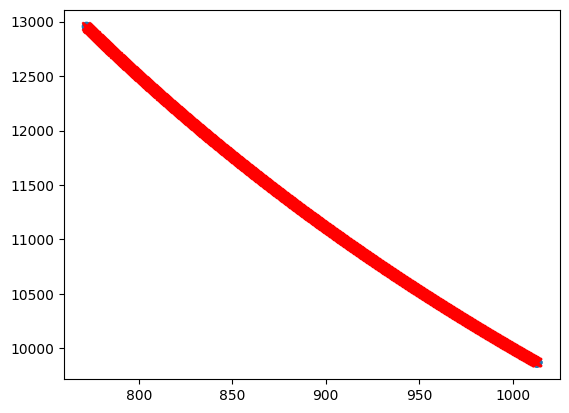

In [14]:
plt.scatter(data['Wavelength'], data['Wavenumber'])
plt.scatter(raman2.wavelength_nm, raman2.wavenumber_cm, color='red', marker='x')

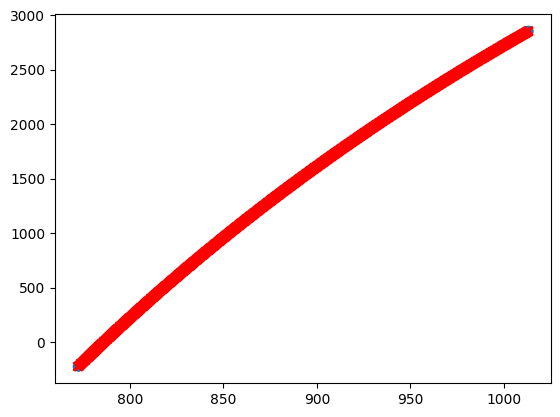

In [15]:
plt.scatter(data['Wavelength'], data['Raman Shift'])
plt.scatter(raman2.wavelength_nm, raman2.shift_cm, color='red', marker='x')

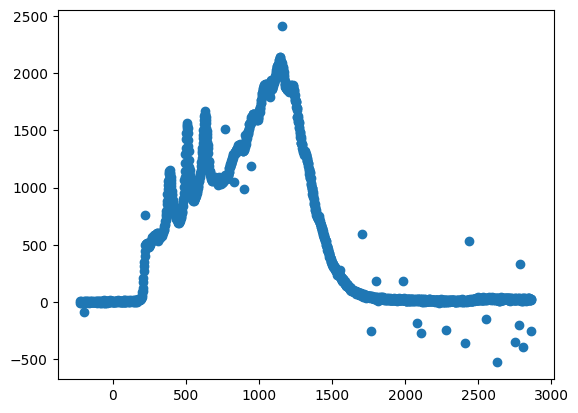

In [16]:
fig, ax = plt.subplots()
ax.scatter(data['Raman Shift'], data['Dark Subtracted #1'])